# Horizontal extent of liquid-containing cloud across the Barrow region

`taylor_hypothesis_cloud_spatial_scale.ipynb` turned a cloud *duration* at
Utqiaġvik into a horizontal *length* with Taylor's frozen-turbulence
hypothesis, using the 40 m tower wind and an arbitrary duration axis. Genie's
observations supply real durations at the site; `comparison_with_Genie_Obs.ipynb`
(section 7b) produced ERA5's own duration distribution at the ARM cell. This
notebook takes the next step in ERA5: **every cell of the Barrow region**, and
**two independent estimates** of cloud width, built on the identical cloud
definition — the `tcc` gate, the fractional LWP/IWP boundaries, the minimum
water paths, the precipitation filter and the Oct 1 – Mar 31 window. The parser
is shared with `plot_lwp_histogram_by_surface_class`, so "identical" is literal.

Domain: **70–80 °N, 165–150 °W**, 41 × 61 = 2,501 cells at 0.25°, the same
region as `map_liquid_containing_hours.ipynb`.

## Method 1 — Taylor's hypothesis, cell by cell

At each cell an **event** is a maximal run of consecutive hours meeting the
liquid-containing criterion, exactly as `liquid_cloud_runs` defines it for the
ARM cell. Its length is $\Delta t$, and

$$L = U\,\Delta t, \qquad U = \overline{\sqrt{u_{10}^2 + v_{10}^2}}$$

with the overbar the mean over the event's hours. The magnitude of the mean
wind *vector* is carried alongside — it is what actually converts a duration
into a displacement, and it is always $\le$ the scalar mean.

Three things carried over from the single-cell construction: a run cannot cross
a gap in the archive or a season boundary; a run touching such a break is
**censored** (a lower bound), kept and counted; a raining hour inside a cloud
splits it into two events, which is the precipitation filter's definition doing
what it says.

**The 10 m wind is a lower bound on the advection speed.** The single-level
archive holds only the 10 m wind, and it covers all eleven seasons. Most
cold-season liquid clouds here are boundary-layer clouds with bases below
500 m, and under a stable Arctic boundary layer the wind increases sharply with
height — the tower notebook found 6.7 m s⁻¹ at 40 m against 5.3 m s⁻¹ at 10 m.
Read every Taylor length in sections 2–5 as conservative. Section 6 replaces
the 10 m wind with the liquid-weighted wind at cloud level from the
pressure-level archive, for the two seasons that archive covers.

## Method 2 — connected components, snapshot by snapshot

No advection hypothesis. At every hour the (lat, lon) field of the
liquid-containing flag is a binary image; its **connected components** are the
clouds and their size is measured directly on the sphere, using the exact
spherical cell areas and a local tangent-plane grid in which zonal separations
are scaled by their own row's cosine. Isolated single cells are components too
and are kept.

Because the components are irregular, "width" has no single direction, so
several measures are computed:

| measure | what it is |
|---|---|
| $d_{eq} = 2\sqrt{A/\pi}$ | diameter of the circle with the same area; rotation-invariant, the standard single-number size of an irregular region (**primary**) |
| extent along the wind | the component's span projected onto its own mean 10 m wind direction — **the chord Taylor's hypothesis estimates**, so the like-for-like partner of method 1 |
| max / min Feret | the longest and shortest span over 18 directions 10° apart; their ratio is the elongation |
| E–W / N–S span | the Feret spans at 0° and 90° |

Every span adds the footprint of one cell along its direction, so a single cell
has a non-zero width. A component touching the domain edge may continue beyond
it: it is flagged, kept, and reported separately — the spatial analogue of a
censored run.

**Connectivity.** Two cells sharing only a corner are joined under
8-connectivity and separated under 4-connectivity. The default is 8; the
sensitivity is reported.

## What is and is not comparable between the two

**The sampling units differ.** Method 1 gives one sample per cell-*event*;
method 2 gives one per component per *hour*, so a deck that persists for twelve
hours is counted twelve times. The duration-weighted Taylor distribution is the
like-for-like companion of the snapshot one, and section 4 draws both. The
cleanest comparison is at one cell: each Taylor event at the ARM cell paired
with the along-wind extent of the component that contained the cell during
those hours.

**The grid cell is not square.** 0.25° of latitude is 27.8 km everywhere; 0.25°
of longitude is 8.9 km at 71.3 °N and 4.8 km at 80 °N. A single-cell component
at the ARM latitude has $d_{eq} \approx 18$ km, an E–W span of 9 km and an N–S
span of 28 km. Every histogram carries these three lengths as dotted reference
lines so the resolution floor is visible rather than mistaken for physics.

## Setup

In [1]:
%load_ext autoreload
%autoreload 2
%matplotlib inline

import warnings
from pathlib import Path

import numpy as np
import matplotlib.pyplot as plt

import cloud_spatial_extent as cse
import plot_lwp_histogram_by_surface_class as lwph

# open_mfdataset warns about join/compat defaults changing; the loader pins
# both explicitly, so the warning is noise here.
warnings.filterwarnings("ignore", category=FutureWarning)
plt.rcParams["figure.dpi"] = 110      # on-screen only; saved files use dpi=

# Set to a directory to write PNGs as well as display them; None displays only.
SAVE_DIR = Path("figures/cloud_spatial_extent")

## Load

The settings are those of `A_precip` in `comparison_with_Genie_Obs.ipynb` and
of the filtered run in `map_liquid_containing_hours.ipynb`, unchanged. One
streaming pass keeps the hourly liquid-containing mask and the 10 m wind at
every cell: about 1.1 GB for eleven seasons, held once so that neither method
re-reads the archive.

In [2]:
SETTINGS = dict(
    region="barrow",
    years=tuple(range(2014, 2025)),   # season START years, matching Genie's span
    season_start=(10, 1), season_end=(3, 31),
    phase_mode="fraction", liquid_fraction_min=0.90, ice_fraction_min=0.850,
    min_lwp=0.01, min_iwp=0.01, min_cloud_fraction=0.95, lsm_tol=0.01,
    storage="local",
)
# The precipitation filter from comparison_with_Genie_Obs.ipynb, unchanged.
PRECIP = dict(no_precip=True, precip_var="rate", precip_rate_max=0.05)   # mm hr-1

E = cse.prepare_extent(**SETTINGS, **PRECIP)

Horizontal extent of liquid-containing cloud, ERA5



  Seasons found (18), coverage of the 182-183-day window:
    1999/2000:  49.7%   (below --min-season-coverage)
    2000/2001: 100.0%  (common year)
    2001/2002:  50.5%  (common year)   (below --min-season-coverage)
    2011/2012: 100.0%
    2012/2013: 100.0%  (common year)
    2013/2014: 100.0%  (common year)
    2014/2015: 100.0%  (common year)
    2015/2016: 100.0%
    2016/2017: 100.0%  (common year)
    2017/2018: 100.0%  (common year)
    2018/2019: 100.0%  (common year)
    2019/2020: 100.0%
    2020/2021: 100.0%  (common year)
    2021/2022: 100.0%  (common year)
    2022/2023: 100.0%  (common year)
    2023/2024: 100.0%
    2024/2025: 100.0%  (common year)
    2025/2026: 100.0%  (common year)
  Source     : /Users/andrewbuggee/Documents/VS_CODE/Python-Research/ERA5/surface_energy_budget/data/barrow
  Grid       : 41 x 61 cells
  Cloudy     : tcc >= 0.95   |   cloud liquid water (tclw)   |   non-precipitating: tp < 0.05 mm hr$^{-1}$
  Seasons    : [2014, 2015, 2016, 2017, 20

  Read in 30 s


  ARM cell   : (71.25 N, -156.50 E), 8.9 km E-W x 27.8 km N-S, d_eq of one cell 17.8 km
  Liquid-containing cell-hours: 40,805,366 of 120,348,120 (33.9%)   |   holes in the hourly record: 0


### Cross-checks against the other notebooks

Two ties, both exact rather than approximate:

1. **Per cell and season, the liquid-containing hours must equal
   `map_liquid_hours`'s `liquid + mixed` counts.** The two are separate passes
   over the archive through the same mask functions; agreement to the hour is
   what makes this notebook's mask the same population as the maps.
2. **At the ARM cell, the events must reproduce section 7b.** With Genie's
   excluded months applied, `fig_monthly_duration_box` reported
   **14,789 h in 2,368 events**; the same hours and events must fall out of the
   domain-wide run detection here.

The first check costs a second full pass (about a minute). Set
`RUN_MAP_CROSS_CHECK = False` to skip it.

In [3]:
RUN_MAP_CROSS_CHECK = True

if RUN_MAP_CROSS_CHECK:
    import map_liquid_hours as mlh
    M = mlh.prepare_maps(**SETTINGS, **PRECIP)
    n_map = M.counts["liquid"] + M.counts["mixed"]           # (season, y, x)
    diff = np.abs(n_map - E.n_liq_season)
    print(f"\nmax |map - extent| liquid-containing hours per cell-season: "
          f"{diff.max():.0f}   (must be 0)")
    assert diff.max() == 0, "the two passes disagree on the mask"
    del M

# Section 7b of comparison_with_Genie_Obs.ipynb drops Genie's excluded months;
# the events here do not, so apply the same exclusion for this check only.
ev_check = cse.taylor_events(E, exclude_months=lwph.GENIE_EXCLUDED_MONTHS)
site = ev_check["is_site"]
print(f"ARM cell with Genie's months excluded: "
      f"{int(ev_check['length_h'][site].sum()):,} h in {int(site.sum()):,} events, "
      f"{int(ev_check['censored'][site].sum())} censored   "
      f"(section 7b: 14,789 h in 2,368 events)")
del ev_check


  Seasons found (18), coverage of the 182-183-day window:
    1999/2000:  49.7%   (below --min-season-coverage)
    2000/2001: 100.0%  (common year)
    2001/2002:  50.5%  (common year)   (below --min-season-coverage)
    2011/2012: 100.0%
    2012/2013: 100.0%  (common year)
    2013/2014: 100.0%  (common year)
    2014/2015: 100.0%  (common year)
    2015/2016: 100.0%
    2016/2017: 100.0%  (common year)
    2017/2018: 100.0%  (common year)
    2018/2019: 100.0%  (common year)
    2019/2020: 100.0%
    2020/2021: 100.0%  (common year)
    2021/2022: 100.0%  (common year)
    2022/2023: 100.0%  (common year)
    2023/2024: 100.0%
    2024/2025: 100.0%  (common year)
    2025/2026: 100.0%  (common year)

  Reading 11 season(s) on the native 41 x 61 grid: [2014, 2015, 2016, 2017, 2018, 2019, 2020, 2021, 2022, 2023, 2024]



max |map - extent| liquid-containing hours per cell-season: 0   (must be 0)


ARM cell with Genie's months excluded: 14,789 h in 2,368 events, 8 censored   (section 7b: 14,789 h in 2,368 events)


## 1. The wind the conversion uses

The 10 m wind speed over the region, all hours and liquid-containing hours,
domain-wide and at the ARM cell. The tower notebook's 40 m median for 2025/26
is marked for scale — it is a different season and a different height, so read
it as a reminder of the shear, not as a comparison.

  -> figures/cloud_spatial_extent/barrow_wind10m_pdf_noprecip0p05mmhr_mean2014-2024.png


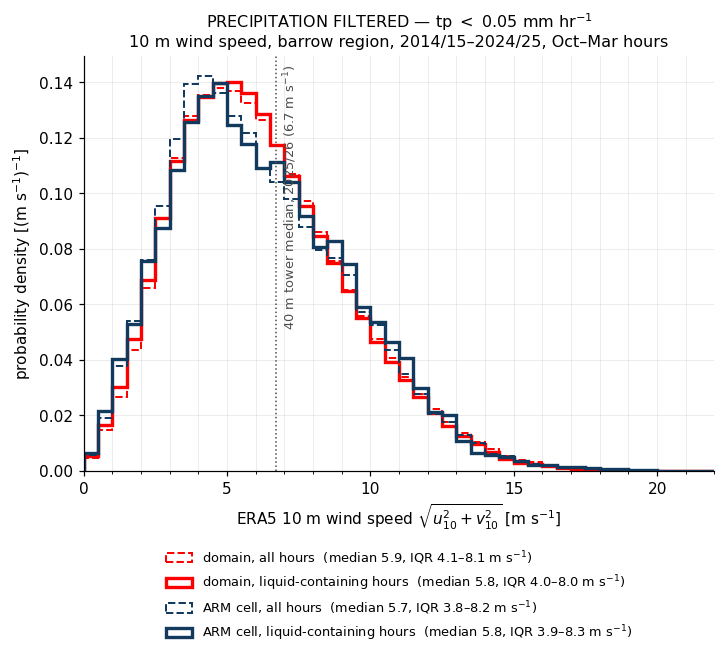

In [4]:
cse.fig_wind_speed_pdf(E, out_dir=SAVE_DIR, tower_median_m_s=6.7,
                       tower_label="40 m tower median, 2025/26 (6.7 m s$^{-1}$)");

## 2. Method 1 — Taylor lengths at every cell

One sample per event. `exclude_months` is left empty: the ARM instrument
outages in `GENIE_EXCLUDED_MONTHS` say nothing about ERA5 over the domain, and
the section 7b construction is reproduced above for the tie alone.

In [5]:
ev = cse.taylor_events(E)
cse.print_taylor_report(E, ev)

Method 1, Taylor: L = U(10 m) x dt   |   non-precipitating: tp < 0.05 mm hr$^{-1}$
  5,346,670 cell-events over 2,501 cells, 40,805,366 liquid-containing cell-hours, 22,946 censored

  all cells: 5,346,670 events
               median      q25      q75     mean      max
    dt            3.0      1.0      9.0      7.6    310.0   [h]


    U             5.7      4.0      7.8      6.1     25.8   [m/s]
    L            68.0     27.7    180.2    170.2   9415.3   [km]


    L_vec        66.6     27.5    173.7    162.0   9351.0   [km]
    1-h events 27%   |   events >= 24 h 7.1%   |   share of hours in events >= 24 h 39%

  ARM cell: 2,619 events
               median      q25      q75     mean      max
    dt            3.0      1.0      7.0      6.3     91.0   [h]
    U             5.5      3.8      7.9      6.0     18.4   [m/s]
    L            55.0     24.1    141.2    141.0   3305.5   [km]
    L_vec        53.8     24.0    138.2    136.7   3301.1   [km]
    1-h events 31%   |   events >= 24 h 4.8%   |   share of hours in events >= 24 h 30%

  by starting month, all cells   [km unless noted]
    month     events  dt med   U med   L med   L q25   L q75   L p90
    Oct    1,034,008       4     6.2      90      34     258     627
    Nov      978,947       4     5.7      87      33     234     526


    Dec      907,222       3     5.5      64      26     166     371
    Jan      793,870       3     5.6      53      24     135     317
    Feb      746,275       3     5.5      55      24     139     300
    Mar      886,348       3     5.8      62      26     152     314


### The distribution of $L$

Log-spaced bins on a log axis: a one-hour event in light wind gives a few km, a
multi-day run gives thousands. The second copy weights every event by its
duration — one count per cell-**hour** rather than per event, which is the
snapshot method's sampling unit and the one that answers "how wide is the cloud
over a randomly chosen cloudy hour".

  -> figures/cloud_spatial_extent/barrow_taylor_hist_L_km_noprecip0p05mmhr_mean2014-2024.png


  -> figures/cloud_spatial_extent/barrow_taylor_hist_L_km_weighted_noprecip0p05mmhr_mean2014-2024.png


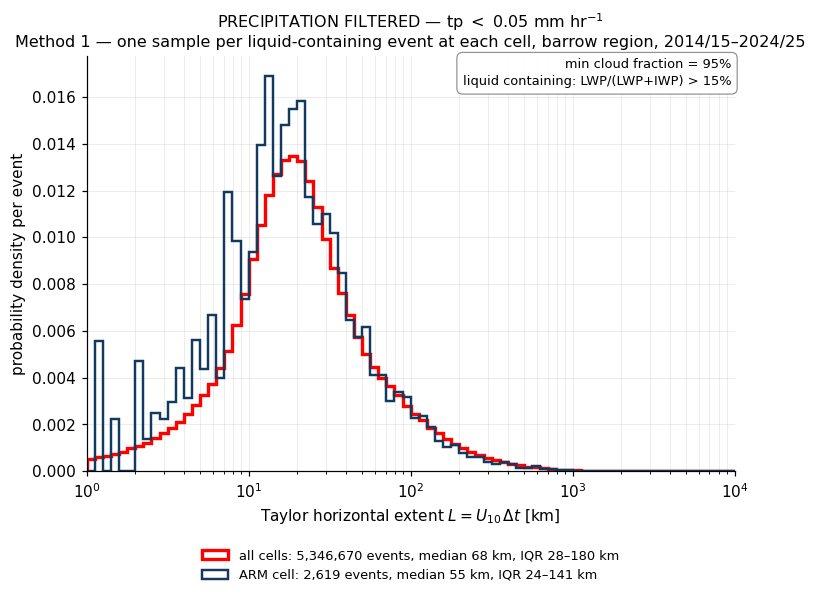

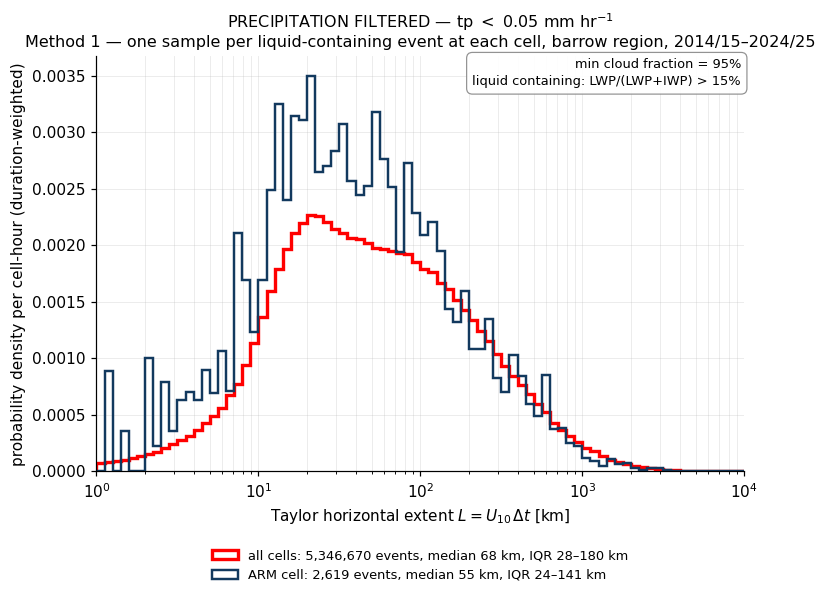

In [6]:
cse.fig_taylor_hist(E, ev, out_dir=SAVE_DIR);
cse.fig_taylor_hist(E, ev, out_dir=SAVE_DIR, weighted=True);

### By month

The companion of section 7b's duration figure, with the duration replaced by
$U\,\Delta t$, and the whole region beside the ARM cell. The 10 m wind barely
varies from month to month in the cold season (section 1), so the monthly
pattern is the duration's.

  -> figures/cloud_spatial_extent/barrow_taylor_monthly_box_L_km_noprecip0p05mmhr_mean2014-2024.png


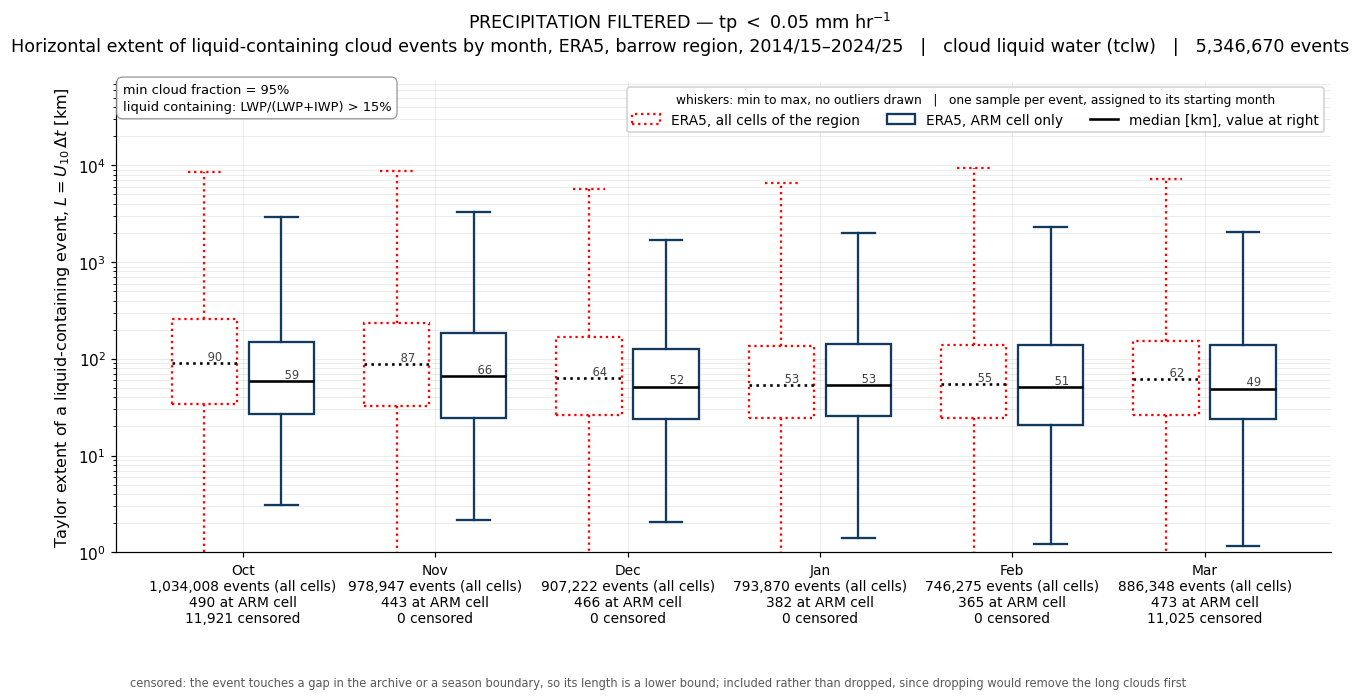

In [7]:
cse.fig_taylor_monthly_box(E, ev, out_dir=SAVE_DIR);

### Where the length comes from — duration, wind, and their product on a map

Per cell, the mean over that cell's events. The mean rather than the median:
a median of whole hours is quantised to 2, 3 or 4 h and draws as a posterised
map, and the mean is dominated by the long events, which is where the hours
are.

  -> figures/cloud_spatial_extent/barrow_taylor_maps_mean_noprecip0p05mmhr_mean2014-2024.png


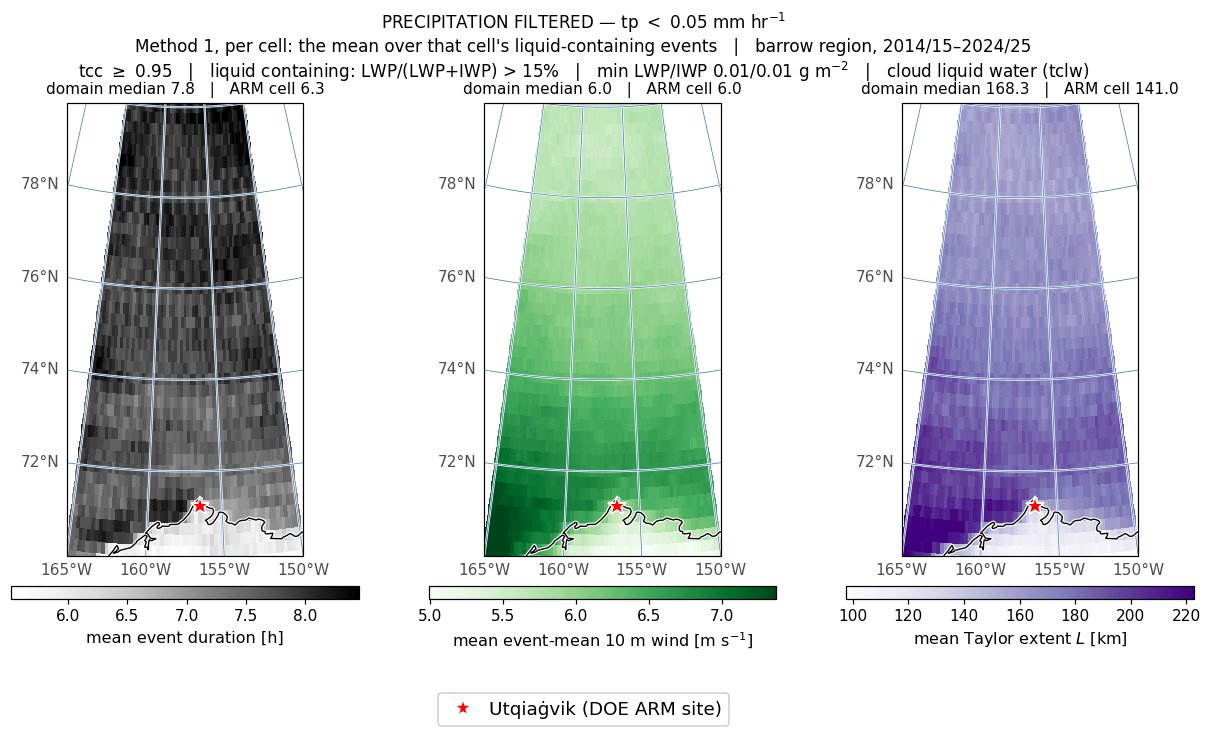

In [8]:
cse.fig_taylor_maps(E, ev, out_dir=SAVE_DIR);

### Scalar mean speed against vector mean wind

$U_{\rm scalar} = \overline{|\mathbf{u}|}$ is what was asked for;
$U_{\rm vector} = |\overline{\mathbf{u}}|$ is the net displacement per unit
time. They differ only when the wind turns during an event, so the gap grows
with duration. Whichever is used, the short events that dominate the count are
unaffected.

In [9]:
ratio = ev["L_vec_km"] / ev["L_km"]
print(f"{'duration':<12}{'events':>10}{'median L_vec / L':>18}{'q10':>8}")
for lo, hi in ((1, 1), (2, 3), (4, 6), (7, 12), (13, 24), (25, 10**6)):
    s = (ev["length_h"] >= lo) & (ev["length_h"] <= hi)
    lab = f"{lo} h" if lo == hi else (f"{lo}-{hi} h" if hi < 10**6 else f">= {lo} h")
    print(f"{lab:<12}{int(s.sum()):>10,}{np.median(ratio[s]):>18.3f}"
          f"{np.percentile(ratio[s], 10):>8.3f}")

duration        events  median L_vec / L     q10
1 h          1,462,914             1.000   1.000
2-3 h        1,279,517             1.000   0.994
4-6 h          900,478             0.998   0.979
7-12 h         802,664             0.995   0.942
13-24 h        544,205             0.986   0.835
>= 25 h        356,892             0.959   0.644


## 3. Method 2 — connected components of the hourly field

### One hour, drawn

The sanity figure: the labelled components at one hour with the 10 m wind, and
each component's $d_{eq}$ over its along-wind extent written at its centroid. An
asterisk marks a component cut by the domain edge. The hour is chosen so that
the ARM cell sits in a mid-sized interior component; change `t_example` to look
at any other.

In [10]:
comp = cse.snapshot_components(E, connectivity=8)
cse.print_snapshot_report(E, comp)

  283,435 component-hours over 48,120 hours, 8-connectivity, 4 s
Method 2, connected components (8-connectivity)   |   non-precipitating: tp < 0.05 mm hr$^{-1}$
  283,435 component-hours   |   single-cell 17.0%   |   touching the domain edge 52.7% of components, 96% of cell-hours
  hours with at least one component: 47,837 of 48,120   |   components per such hour: median 5

  all components: 283,435
                       median      q25      q75      p90      max
    d_eq_km              45.7     24.9    122.2    340.1    797.5
    extent_wind_km       59.6     29.3    178.9    493.6   1220.9
    feret_max_km         72.3     33.1    215.3    591.7   1220.9
    feret_min_km         34.6     16.7    111.2    333.6    579.3
    span_ew_km           45.2     16.7    151.0    426.3    579.9
    span_ns_km           55.6     27.8    166.8    444.8   1139.7
    n_cells               8.0      2.0     58.0    453.0   2501.0
    U_mean_m_s            5.1      3.5      7.1      9.4     23.1
   

  -> figures/cloud_spatial_extent/barrow_snapshot_example_2020-11-19T16_noprecip0p05mmhr_mean2014-2024.png


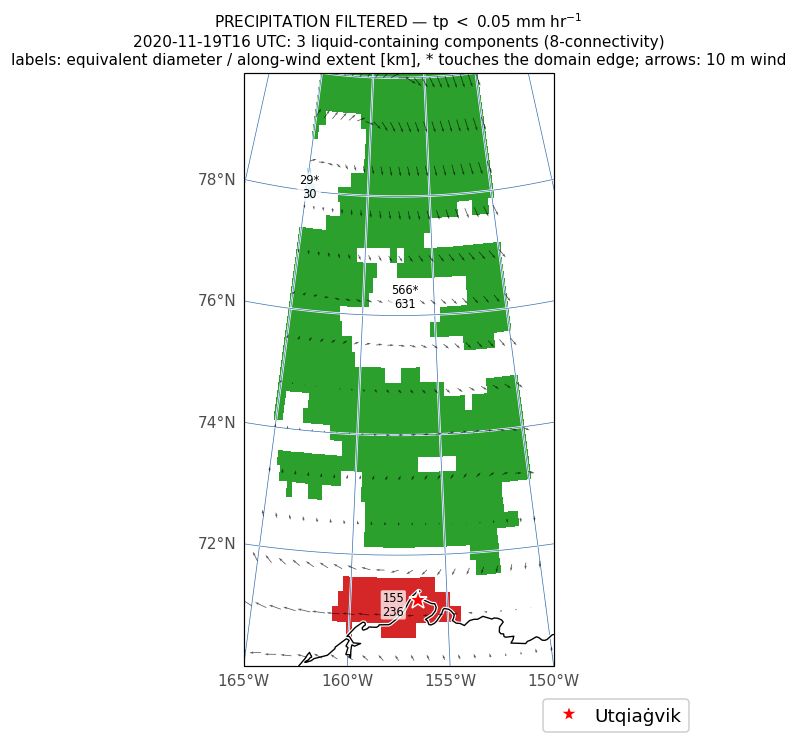

In [11]:
# An hour where the ARM cell is inside a component of 60-200 km that does not
# touch the domain edge; the middle such hour in the record.
sel = comp["has_site"] & ~comp["touches_edge"] & (comp["d_eq_km"] > 60) & (comp["d_eq_km"] < 200)
cands = comp["t"][sel]
t_example = int(cands[len(cands) // 2]) if cands.size else int(comp["t"][comp["has_site"]][0])
cse.fig_snapshot_example(E, comp, t_example, out_dir=SAVE_DIR);

### The size distributions

One count per component-hour. The four measures are the same objects sized four
ways, so their ordering is fixed by construction:
min Feret ≤ $d_{eq}$ ≲ along-wind extent ≤ max Feret. The reference lines mark
what one cell looks like under each: the cell is 9 km E–W, 18 km in $d_{eq}$
and 28 km N–S, so single-cell components populate three different places on the
axis depending on the measure.

The second figure keeps only the components that do **not** touch the domain
edge. It is the honest histogram of *resolved* cloud sizes, at the price of
discarding the large decks — which, as the report above shows, hold most of the
liquid-containing cell-hours.

  -> figures/cloud_spatial_extent/barrow_snapshot_hist_noprecip0p05mmhr_mean2014-2024.png
  -> figures/cloud_spatial_extent/barrow_snapshot_hist_interior_noprecip0p05mmhr_mean2014-2024.png


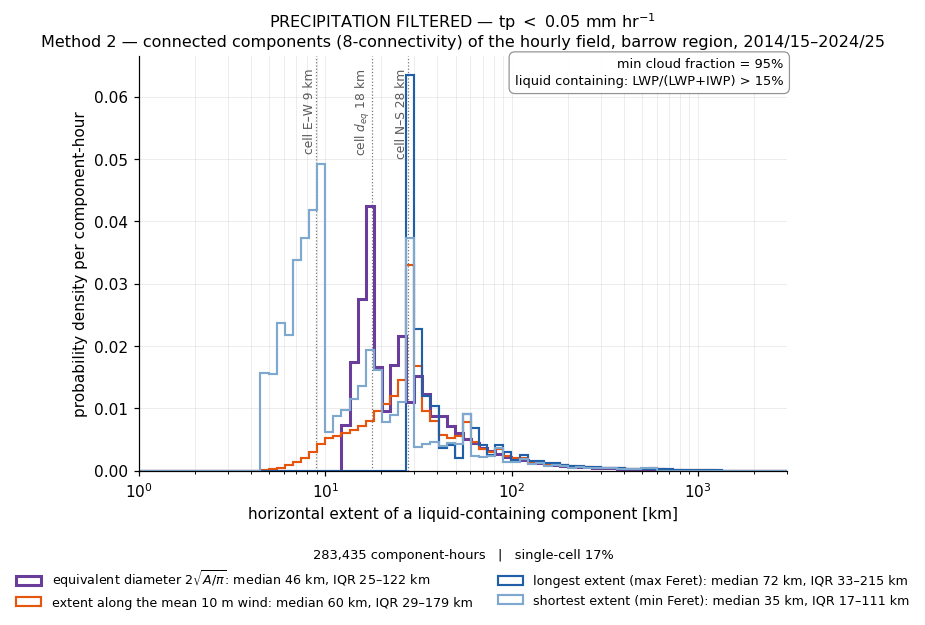

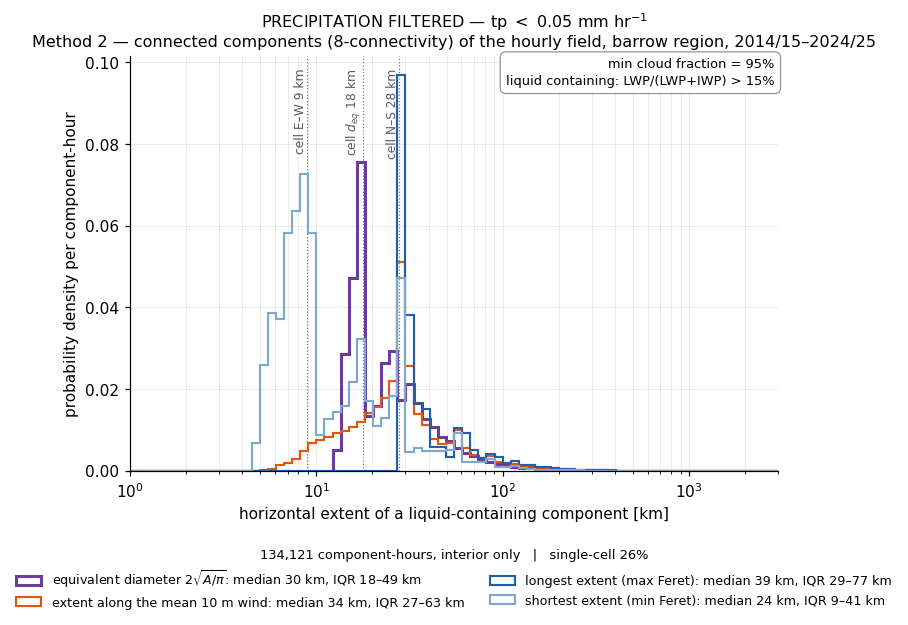

In [12]:
cse.fig_snapshot_hist(E, comp, out_dir=SAVE_DIR);
cse.fig_snapshot_hist(E, comp, out_dir=SAVE_DIR, interior_only=True);

### By month, and on a map

Boxes: all components beside those that contain the ARM cell. Maps: per cell,
the median size of the component the cell belonged to over its
liquid-containing hours — the size of the cloud a cell is typically *part of*.
Cells near the boundary are biased low, since a component there is cut by the
domain edge.

  -> figures/cloud_spatial_extent/barrow_snapshot_monthly_box_extent_wind_km_noprecip0p05mmhr_mean2014-2024.png


  -> figures/cloud_spatial_extent/barrow_snapshot_maps_noprecip0p05mmhr_mean2014-2024.png


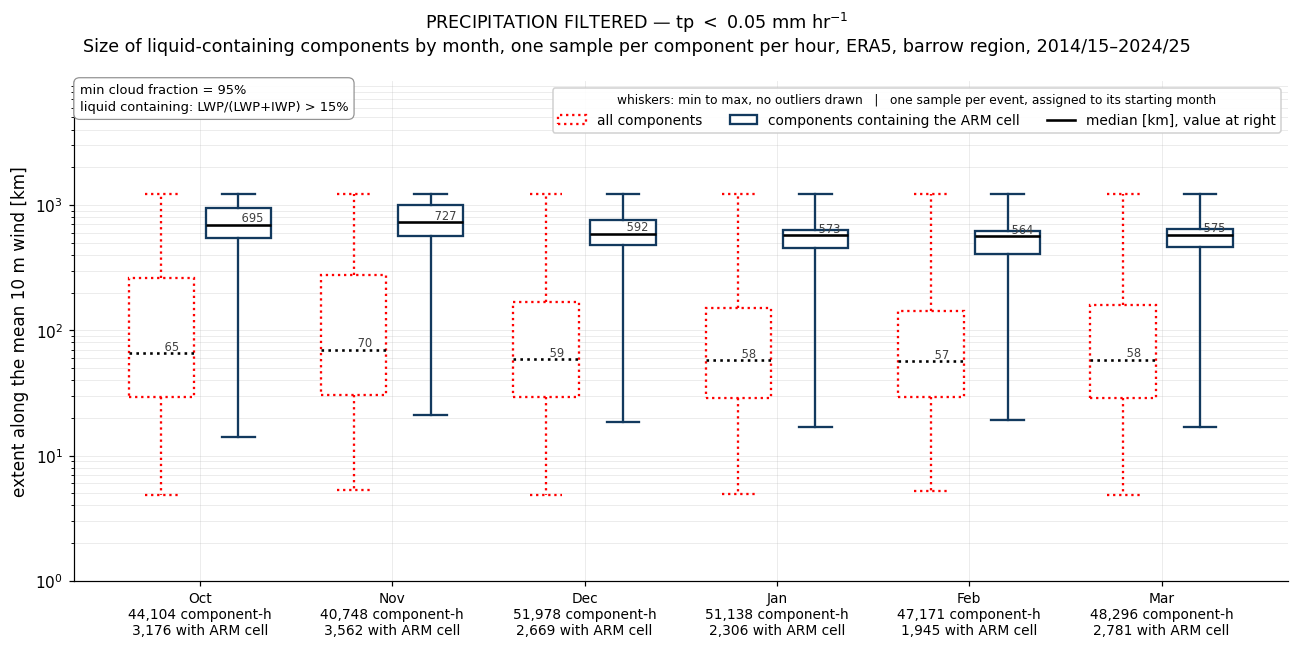

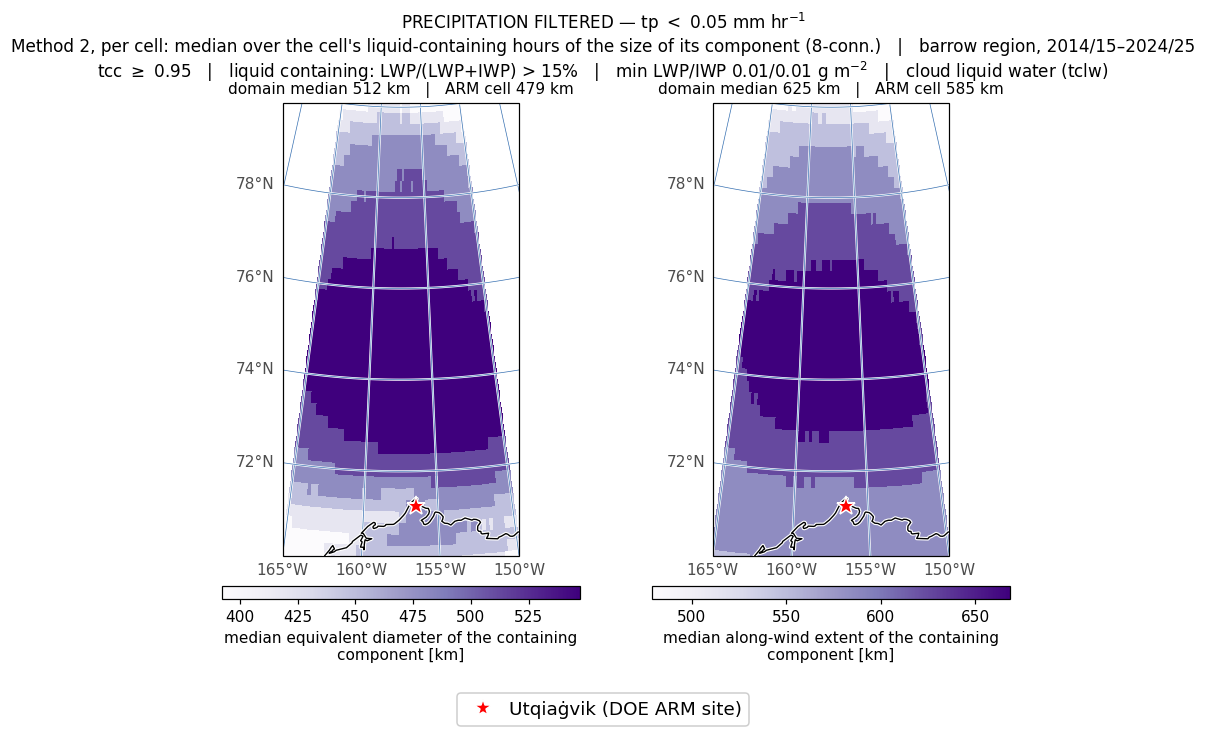

In [13]:
cse.fig_snapshot_monthly_box(E, comp, out_dir=SAVE_DIR, key="extent_wind_km");
cse.fig_snapshot_maps(E, comp, out_dir=SAVE_DIR);

### Sensitivity to connectivity

4-connectivity splits corner-touching cells that 8-connectivity joins, so it
yields more, smaller components. The difference is the number of clouds that
hang together by a corner alone.

In [14]:
comp4 = cse.snapshot_components(E, connectivity=4)
print(f"{'':<22}{'8-conn':>12}{'4-conn':>12}")
for lab, fn in (("component-hours", lambda c: f"{c['t'].size:,}"),
                ("single-cell share", lambda c: f"{100*np.mean(c['n_cells']==1):.1f}%"),
                ("median d_eq [km]", lambda c: f"{np.median(c['d_eq_km']):.1f}"),
                ("median along-wind [km]", lambda c: f"{np.median(c['extent_wind_km']):.1f}"),
                ("q75 d_eq [km]", lambda c: f"{np.percentile(c['d_eq_km'], 75):.1f}"),
                ("interior median d_eq", lambda c: f"{np.median(c['d_eq_km'][~c['touches_edge']]):.1f}")):
    print(f"{lab:<22}{fn(comp):>12}{fn(comp4):>12}")
del comp4

  323,161 component-hours over 48,120 hours, 4-connectivity, 3 s
                            8-conn      4-conn
component-hours            283,435     323,161
single-cell share            17.0%       19.9%
median d_eq [km]              45.7        40.5
median along-wind [km]        59.6        53.1
q75 d_eq [km]                122.2       104.0
interior median d_eq          30.2        28.0


## 4. The two methods against each other

**(a)** Over the whole region. The per-event Taylor distribution is dominated by
short events; weighted by duration it is the distribution over cell-hours and
sits where the snapshot distributions sit or beyond them.

**(b)** At the ARM cell, one point per event: its Taylor $L$ against the mean,
over its hours, of the along-wind extent of the component that contained the
cell. A point on the 1:1 line is an event whose duration times wind speed
matches the width of the cloud that was actually there — the frozen-field
picture. Points **below** the line are events that ended long before the cloud
edge could have advected past: the liquid-containing *state* at the cell
switched off while the cell was still inside a large deck, which is the
phase-threshold flickering, not the cloud leaving.

  -> figures/cloud_spatial_extent/barrow_method_comparison_noprecip0p05mmhr_mean2014-2024.png
ARM cell, 2619 events: median L / snapshot along-wind extent = 0.15
duration      events  median ratio   share within x2 of 1:1
1 h              804          0.06                       4%
2-3 h            680          0.11                       5%
4-6 h            428          0.20                       8%
7-12 h           357          0.28                      20%
13-24 h          231          0.57                      58%
>= 25 h          119          1.02                      74%


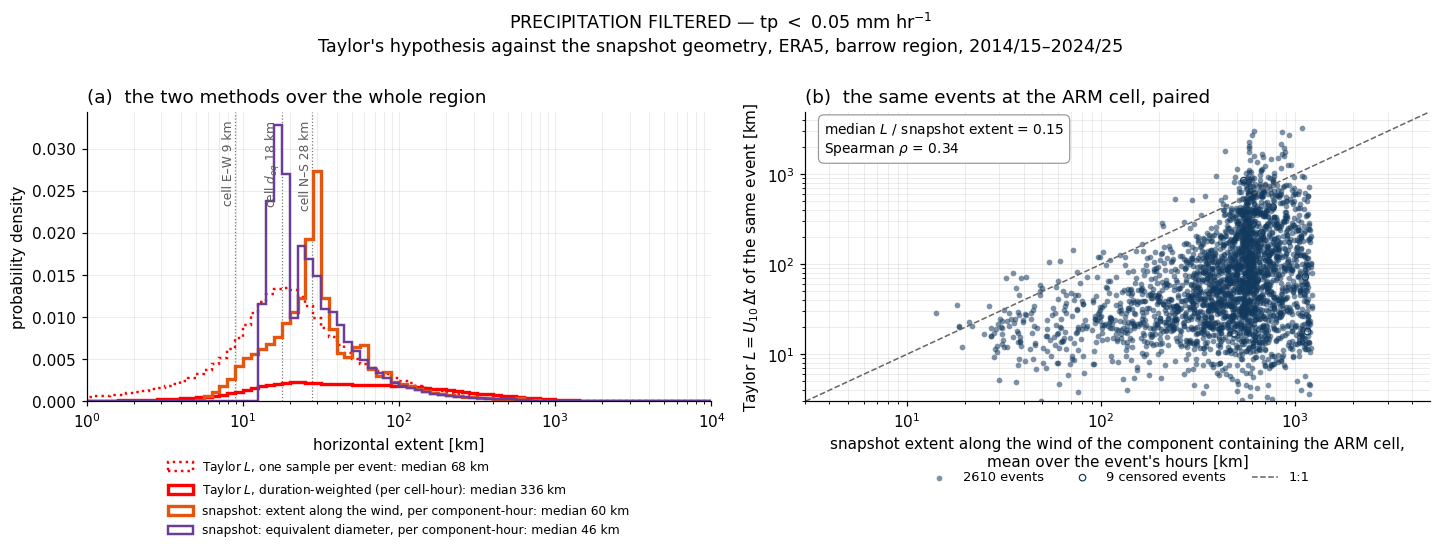

In [15]:
cse.fig_method_comparison(E, ev, comp, out_dir=SAVE_DIR);

pairs = cse.site_event_pairs(E, ev, comp)
r = pairs["L_km"] / pairs["snapshot_extent_wind_km"]
print(f"ARM cell, {r.size} events: median L / snapshot along-wind extent = {np.median(r):.2f}")
print(f"{'duration':<12}{'events':>8}{'median ratio':>14}{'share within x2 of 1:1':>25}")
for lo, hi in ((1, 1), (2, 3), (4, 6), (7, 12), (13, 24), (25, 10**6)):
    s = (pairs["length_h"] >= lo) & (pairs["length_h"] <= hi)
    if not s.any():
        continue
    lab = f"{lo} h" if lo == hi else (f"{lo}-{hi} h" if hi < 10**6 else f">= {lo} h")
    print(f"{lab:<12}{int(s.sum()):>8}{np.median(r[s]):>14.2f}"
          f"{100*np.mean((r[s] > 0.5) & (r[s] < 2)):>24.0f}%")

## 5. All sky, for reference

The precipitation filter splits runs at every raining hour and removes raining
cells from the components, so it shortens both estimates. The unfiltered
headline numbers, for the size of that effect. Nothing else is drawn for this
variant; every figure above takes an `ExtentAnalysis` and can be called with
`E_all` in place of `E`.

In [16]:
E_all = cse.prepare_extent(**SETTINGS)
ev_all = cse.taylor_events(E_all)
comp_all = cse.snapshot_components(E_all)
print()
print(f"{'':<34}{'filtered':>12}{'all sky':>12}")
rows = [
    ("events (all cells)", f"{ev['L_km'].size:,}", f"{ev_all['L_km'].size:,}"),
    ("median event duration [h]", f"{np.median(ev['length_h']):.0f}", f"{np.median(ev_all['length_h']):.0f}"),
    ("median Taylor L [km]", f"{np.median(ev['L_km']):.0f}", f"{np.median(ev_all['L_km']):.0f}"),
    ("duration-weighted median L [km]", f"{cse._weighted_median(ev['L_km'], ev['length_h']):.0f}",
     f"{cse._weighted_median(ev_all['L_km'], ev_all['length_h']):.0f}"),
    ("component-hours", f"{comp['t'].size:,}", f"{comp_all['t'].size:,}"),
    ("median d_eq [km]", f"{np.median(comp['d_eq_km']):.0f}", f"{np.median(comp_all['d_eq_km']):.0f}"),
    ("median along-wind extent [km]", f"{np.median(comp['extent_wind_km']):.0f}",
     f"{np.median(comp_all['extent_wind_km']):.0f}"),
    ("ARM cell: median containing d_eq [km]", f"{np.nanmedian(comp['site_d_eq_km']):.0f}",
     f"{np.nanmedian(comp_all['site_d_eq_km']):.0f}"),
]
for lab, a, b in rows:
    print(f"{lab:<34}{a:>12}{b:>12}")
del E_all, ev_all, comp_all

Horizontal extent of liquid-containing cloud, ERA5



  Seasons found (18), coverage of the 182-183-day window:
    1999/2000:  49.7%   (below --min-season-coverage)
    2000/2001: 100.0%  (common year)
    2001/2002:  50.5%  (common year)   (below --min-season-coverage)
    2011/2012: 100.0%
    2012/2013: 100.0%  (common year)
    2013/2014: 100.0%  (common year)
    2014/2015: 100.0%  (common year)
    2015/2016: 100.0%
    2016/2017: 100.0%  (common year)
    2017/2018: 100.0%  (common year)
    2018/2019: 100.0%  (common year)
    2019/2020: 100.0%
    2020/2021: 100.0%  (common year)
    2021/2022: 100.0%  (common year)
    2022/2023: 100.0%  (common year)
    2023/2024: 100.0%
    2024/2025: 100.0%  (common year)
    2025/2026: 100.0%  (common year)
  Source     : /Users/andrewbuggee/Documents/VS_CODE/Python-Research/ERA5/surface_energy_budget/data/barrow
  Grid       : 41 x 61 cells
  Cloudy     : tcc >= 0.95   |   cloud liquid water (tclw)   |   no precipitation filter
  Seasons    : [2014, 2015, 2016, 2017, 2018, 2019, 2020, 20

  Read in 27 s


  ARM cell   : (71.25 N, -156.50 E), 8.9 km E-W x 27.8 km N-S, d_eq of one cell 17.8 km
  Liquid-containing cell-hours: 46,077,149 of 120,348,120 (38.3%)   |   holes in the hourly record: 0


  268,727 component-hours over 48,120 hours, 8-connectivity, 4 s

                                      filtered     all sky


events (all cells)                   5,346,670   5,412,907
median event duration [h]                    3           4
median Taylor L [km]                        68          73
duration-weighted median L [km]            336         407
component-hours                        283,435     268,727
median d_eq [km]                            46          48
median along-wind extent [km]               60          62
ARM cell: median containing d_eq [km]         482         534


## 6. The wind at cloud level, from the pressure-level archive

Everything above takes $U$ from the 10 m wind. Under a stable Arctic boundary
layer that is a **lower bound** on the wind a few hundred metres up where the
liquid sits, so every Taylor length above is conservative by an unknown
factor. The pressure-level archive (`data/barrow_pressure`) removes the guess:
it holds specific cloud liquid water `clwc` on 23 levels for two complete cold
seasons, **2024/25 and 2025/26**, and — once fetched — the wind components on
the same levels.

**What is computed.** Hydrostatic balance puts $dp/g$ kg of air above unit area
between two pressure surfaces, so the liquid mass in the layer that level $k$
owns is $w_k = \mathrm{clwc}_k\,\Delta p_k/g$, with $\Delta p_k$ clipped at the
surface pressure so a level under the terrain contributes nothing. The
cloud-level wind is the **liquid-mass-weighted** mean over levels,

$$U_{cl} = \frac{\sum_k w_k\,|\mathbf{u}_k|}{\sum_k w_k}, \qquad
p_{cl} = \frac{\sum_k w_k\,p_k}{\sum_k w_k}$$

evaluated only at cell-hours the single-level filter calls liquid-containing,
so the population is the one every other figure uses. Weighting by liquid
mass answers the question asked — where is the liquid and how fast is it
moving — and $\sum_k w_k$ is the pressure-level LWP, checkable against `tclw`.
$p_{cl}$ needs only `clwc`, so the "where is the liquid" figure is available
before the winds are.

**Two things the levels miss.** About 15% of liquid cell-hours hold no liquid
on the 23 levels at all (a thin layer the levels straddle); those take the
wind at 950 hPa, the median $p_{cl}$, and are counted. The winds are fetched
on the 16 levels from 1000 to 500 hPa; the cell below reports the share of
liquid mass above that, measured from the cloud-water archive itself.

**The comparison is made on the two seasons the archive covers**, with the
10 m estimate recomputed on the same hours rather than borrowed from the
eleven-season run. 2025/26 lies beyond Genie's span.

In [17]:
import cloud_level_wind as clw

# The two cold seasons the pressure-level archive holds.
E_pl = cse.prepare_extent(**{**SETTINGS, "years": (2024, 2025)}, **PRECIP)
CL = clw.cloud_level_wind(E_pl)
print()
clw.print_cloud_wind_report(E_pl, CL)

Horizontal extent of liquid-containing cloud, ERA5



  Seasons found (18), coverage of the 182-183-day window:
    1999/2000:  49.7%   (below --min-season-coverage)
    2000/2001: 100.0%  (common year)
    2001/2002:  50.5%  (common year)   (below --min-season-coverage)
    2011/2012: 100.0%
    2012/2013: 100.0%  (common year)
    2013/2014: 100.0%  (common year)
    2014/2015: 100.0%  (common year)
    2015/2016: 100.0%
    2016/2017: 100.0%  (common year)
    2017/2018: 100.0%  (common year)
    2018/2019: 100.0%  (common year)
    2019/2020: 100.0%
    2020/2021: 100.0%  (common year)
    2021/2022: 100.0%  (common year)
    2022/2023: 100.0%  (common year)
    2023/2024: 100.0%
    2024/2025: 100.0%  (common year)
    2025/2026: 100.0%  (common year)
  Source     : /Users/andrewbuggee/Documents/VS_CODE/Python-Research/ERA5/surface_energy_budget/data/barrow
  Grid       : 41 x 61 cells
  Cloudy     : tcc >= 0.95   |   cloud liquid water (tclw)   |   non-precipitating: tp < 0.05 mm hr$^{-1}$
  Seasons    : [2024, 2025]
  Hours kept :

  Read in 5 s


  ARM cell   : (71.25 N, -156.50 E), 8.9 km E-W x 27.8 km N-S, d_eq of one cell 17.8 km
  Liquid-containing cell-hours: 8,182,602 of 21,848,736 (37.5%)   |   holes in the hourly record: 0


  cloud-level wind: 8,736 hours with cloud water on levels, 8,736 with winds   |   1,024,299 of 8,182,602 liquid cell-hours (12.5%) hold no liquid on the levels, 1,024,299 of those given the 950 hPa wind   |   30 s

Cloud level, liquid-mass weighted   |   non-precipitating: tp < 0.05 mm hr$^{-1}$
  hours in the cloud-water archive: 8,736 of 8,736;  with winds: 8,736


  liquid-weighted pressure at liquid cell-hours: median 948 hPa, IQR 903-975, p10 863, p90 999
  share of liquid cell-hours with p_cl > 850 hPa: 93%   > 700 hPa: 100%
  liquid mass above 500 hPa (the top wind level): 0.002% of the total on the levels
  liquid cell-hours with no liquid on the levels: 1,024,299 of 8,182,602 (12.5%); 1,024,299 given the 950 hPa wind
  8,182,602 liquid cell-hours with a cloud-level wind
  U_cl: median 8.5 m/s, IQR 5.6-11.6   |   U_10 same hours: median 5.9


  U_cl / U_10 per cell-hour: median 1.41, IQR 1.19-1.68
  liquid above the wind levels: mean share 0.00% of the column's liquid


  -> figures/cloud_spatial_extent/barrow_cloud_level_pressure_noprecip0p05mmhr_mean2024-2025.png


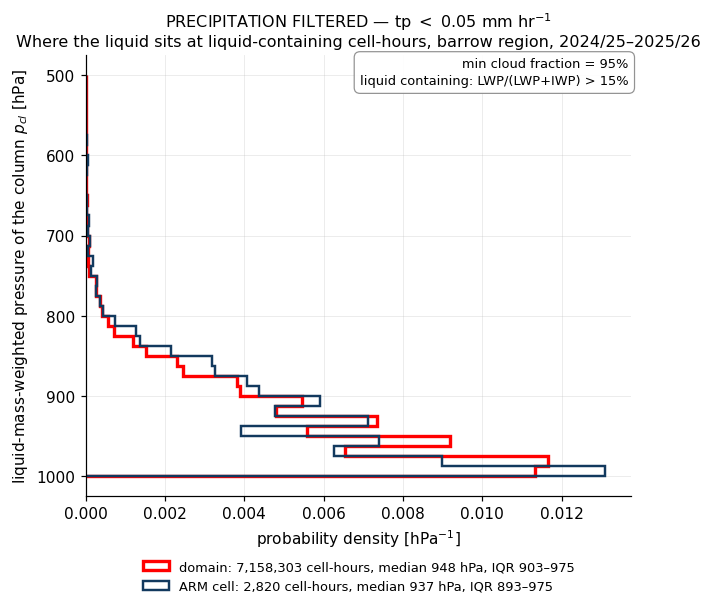

In [18]:
clw.fig_liquid_level(E_pl, CL, out_dir=SAVE_DIR);

### Taylor lengths with the cloud-level wind

The winds are a separate download, kept in their own directory
(`data/barrow_pressure_wind`) because the downloader resumes in date space and
a second variable set in the same directory would be skipped as already
present. Until they exist the cell below prints the two commands that fetch
them (one per season, 18 requests each, about 0.7 GB written per season); once
they do, it draws the same events with both winds.

The events are identical under both winds — they come from the mask alone —
so panel (b) of the Taylor figure is a one-to-one comparison and the ratio
$L_{cl}/L_{10}$ per event is the event-mean $U_{cl}/U_{10}$. The last lines
redo the section 4 pairing against the snapshot extents with the cloud-level
wind, which is where a larger $U$ should move the short events toward the 1:1
line if advection, rather than the state flickering, ended them.

1,055,683 events in the two seasons, 1,055,683 with a cloud-level wind on at least one hour

Method 1, Taylor: L = U(10 m) x dt   |   non-precipitating: tp < 0.05 mm hr$^{-1}$
  1,055,683 cell-events over 2,501 cells, 8,182,602 liquid-containing cell-hours, 4,680 censored

  all cells: 1,055,683 events
               median      q25      q75     mean      max
    dt            3.0      1.0      9.0      7.8    292.0   [h]
    U             8.7      5.9     12.0      9.3     41.5   [m/s]
    L           105.0     42.4    276.4    248.3  12428.4   [km]
    L_vec       103.0     42.1    268.2    236.1  12306.3   [km]
    1-h events 27%   |   events >= 24 h 7.2%   |   share of hours in events >= 24 h 40%

  ARM cell: 508 events
               median      q25      q75     mean      max
    dt            3.0      1.0      7.0      6.0     65.0   [h]
    U             8.1      5.2     11.4      8.6     24.9   [m/s]
    L            89.7     35.7    190.8    184.7   2449.9   [km]
    L_vec    

  -> figures/cloud_spatial_extent/barrow_cloud_wind_vs_10m_noprecip0p05mmhr_mean2024-2025.png


  -> figures/cloud_spatial_extent/barrow_cloud_wind_ratio_maps_noprecip0p05mmhr_mean2024-2025.png


  -> figures/cloud_spatial_extent/barrow_taylor_cloud_wind_noprecip0p05mmhr_mean2024-2025.png


  -> figures/cloud_spatial_extent/barrow_taylor_monthly_box_two_winds_noprecip0p05mmhr_mean2024-2025.png


  52,298 component-hours over 8,736 hours, 8-connectivity, 1 s

ARM cell, 10 m wind: 508 events, median L / snapshot along-wind extent = 0.15
  1-3 h        282 events   median ratio 0.08   within x2 of 1:1 5%
  4-12 h       161 events   median ratio 0.21   within x2 of 1:1 11%
  13-24 h       47 events   median ratio 0.54   within x2 of 1:1 55%
  >= 25 h       18 events   median ratio 0.99   within x2 of 1:1 83%

ARM cell, cloud-level wind: 508 events, median L / snapshot along-wind extent = 0.22
  1-3 h        282 events   median ratio 0.12   within x2 of 1:1 7%
  4-12 h       161 events   median ratio 0.30   within x2 of 1:1 24%
  13-24 h       47 events   median ratio 0.78   within x2 of 1:1 74%
  >= 25 h       18 events   median ratio 1.47   within x2 of 1:1 67%


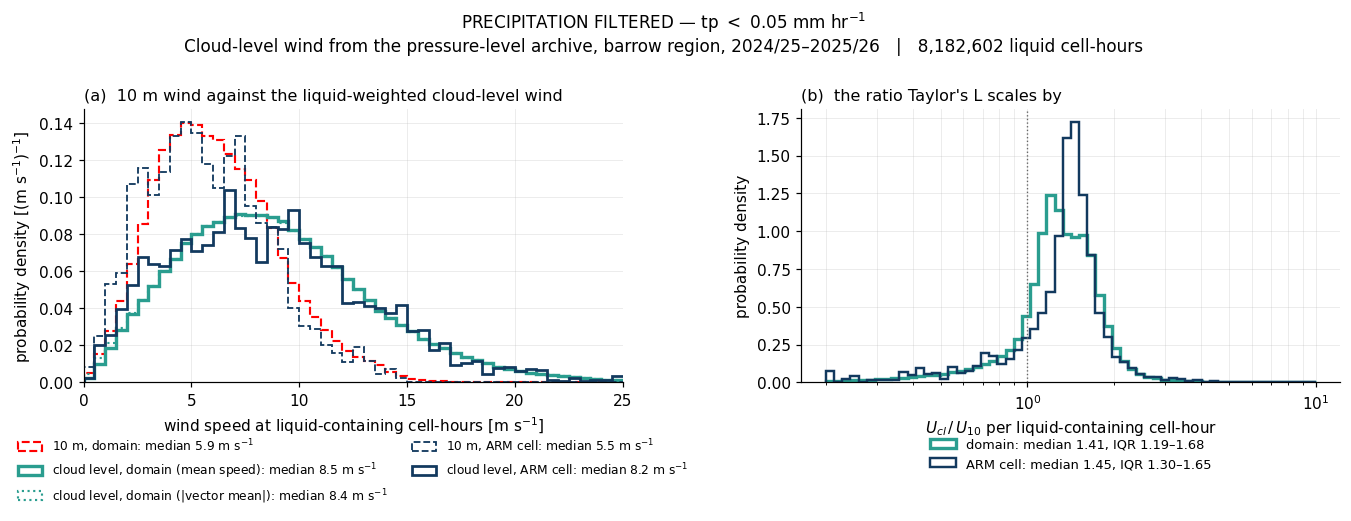

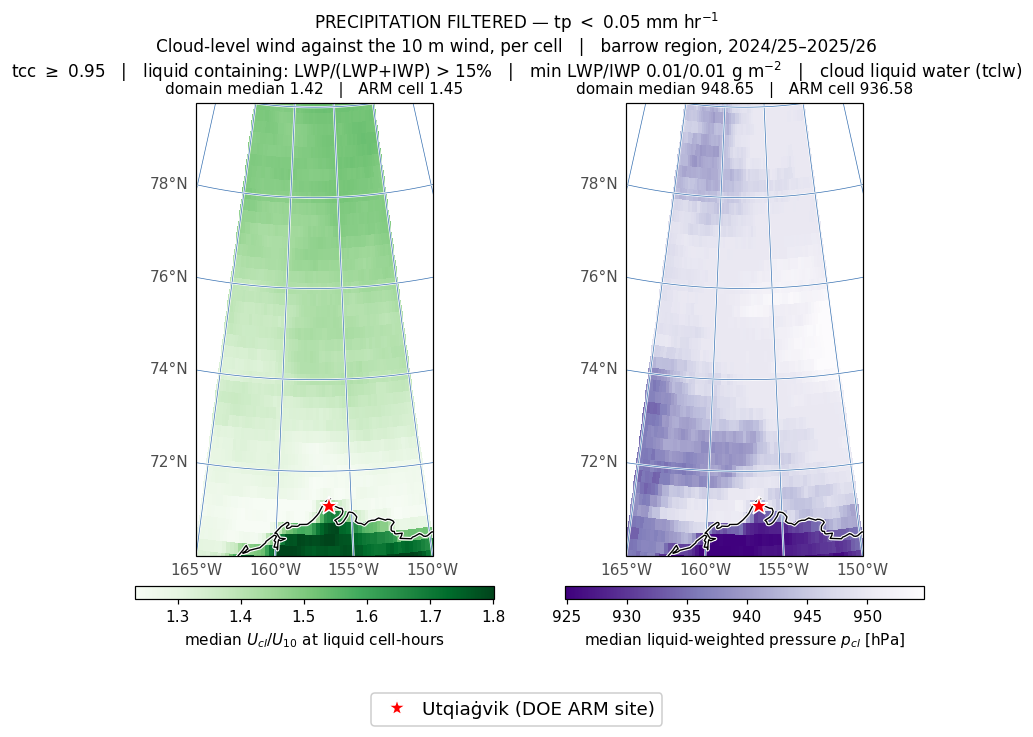

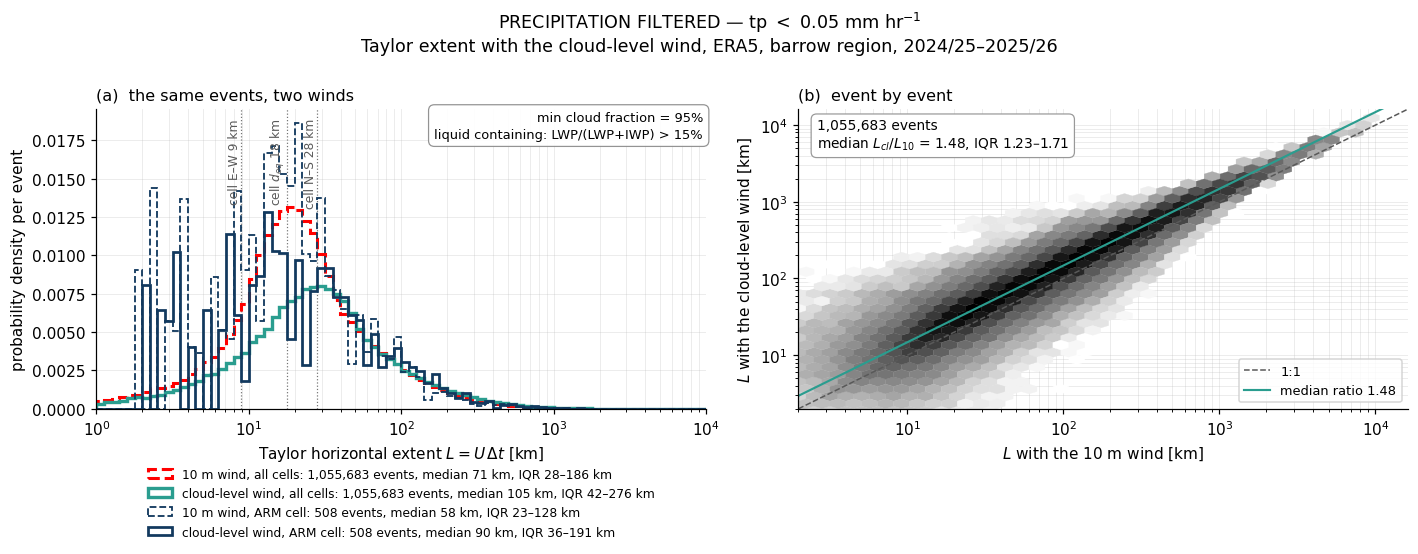

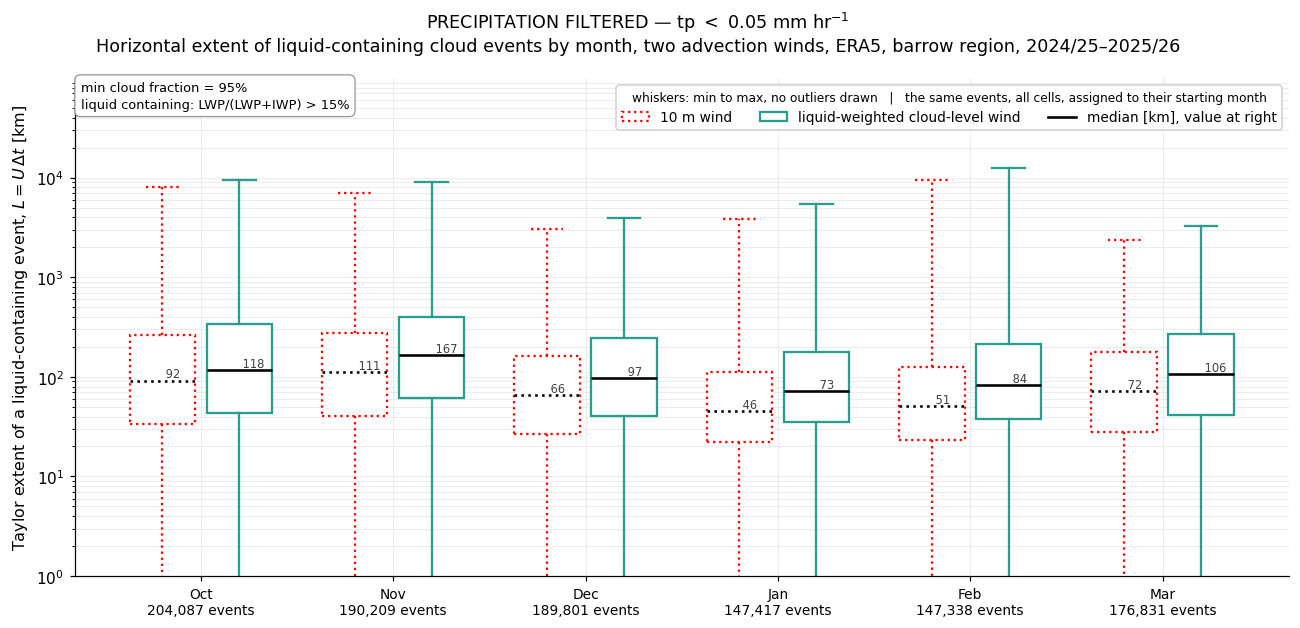

In [19]:
if CL["has_wind"].any():
    ev10_pl = cse.taylor_events(E_pl)
    evcl_pl = cse.taylor_events(E_pl, wind=(CL["u_cl_m_s"], CL["v_cl_m_s"]))
    ok = np.isfinite(evcl_pl["L_km"])
    print(f"{ev10_pl['L_km'].size:,} events in the two seasons, {int(ok.sum()):,} "
          f"with a cloud-level wind on at least one hour\n")
    cse.print_taylor_report(E_pl, {k: (v[ok] if isinstance(v, np.ndarray) else v)
                                   for k, v in evcl_pl.items()})

    clw.fig_cloud_wind_vs_10m(E_pl, CL, out_dir=SAVE_DIR)
    clw.fig_ratio_map(E_pl, CL, out_dir=SAVE_DIR)
    clw.fig_taylor_cloud_wind(E_pl, ev10_pl, evcl_pl, out_dir=SAVE_DIR)
    clw.fig_taylor_monthly_box_two_winds(E_pl, ev10_pl, evcl_pl, out_dir=SAVE_DIR)

    # The section 4 pairing at the ARM cell, with both winds.
    comp_pl = cse.snapshot_components(E_pl)
    for lab, ev_i in (("10 m wind", ev10_pl), ("cloud-level wind", evcl_pl)):
        pr = cse.site_event_pairs(E_pl, ev_i, comp_pl)
        r = pr["L_km"] / pr["snapshot_extent_wind_km"]
        r_ok = np.isfinite(r)
        print(f"\nARM cell, {lab}: {int(r_ok.sum())} events, median L / snapshot "
              f"along-wind extent = {np.median(r[r_ok]):.2f}")
        for lo, hi in ((1, 3), (4, 12), (13, 24), (25, 10**6)):
            s = r_ok & (pr["length_h"] >= lo) & (pr["length_h"] <= hi)
            if s.any():
                lab_d = f"{lo}-{hi} h" if hi < 10**6 else f">= {lo} h"
                print(f"  {lab_d:<10}{int(s.sum()):>6} events   median ratio "
                      f"{np.median(r[s]):.2f}   within x2 of 1:1 "
                      f"{100 * np.mean((r[s] > 0.5) & (r[s] < 2)):.0f}%")
else:
    print("No wind archive yet. Fetch it with, one season per call:\n")
    for a, b in (("2024-10-01", "2025-03-31"), ("2025-10-01", "2026-03-31")):
        print("  " + clw.download_command(E_pl, a, b))
    print("\nThen re-run this cell.")

## Reading the results

Three things to keep separate:

1. **The event is a state, not a cloud.** A Taylor event ends when the cell
   stops meeting the criterion — `tcc` dipping under 0.95, the liquid share
   dropping under 15%, an hour of drizzle — not when the cloud's edge passes.
   Section 4(b) measures how often those coincide. Where they do not, $L$ is the
   persistence length of the *liquid-containing state* along the wind, which is
   a real quantity but a different one from cloud width.
2. **The domain is smaller than the decks.** The snapshot report gives the share
   of liquid-containing cell-hours sitting in components that touch the domain
   boundary. Where that share is large, the snapshot method's upper tail is set
   by the box, not by the clouds, and only the interior histogram is a
   resolved size distribution. A wider download would fix this; nothing in the
   code assumes the domain size.
3. **Neither method resolves anything below the cell.** Taylor cannot see less
   than one hour of advection; the components cannot see less than one cell,
   and a cell is three times taller than it is wide. Below roughly 30 km both
   distributions are shaped by the grid.

**Next steps.** Section 6 replaces the 10 m lower bound with the
liquid-weighted cloud-level wind for the two seasons the pressure archive
covers; the Doppler-lidar profiles at the site would do the same for the
observations. Tracking components between consecutive hours would
turn method 2 into a lifetime and speed estimate that could test the frozen
field assumption directly, rather than by proxy through section 4(b).